In [1]:
import requests
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = "https://data.cityofnewyork.us/resource/h9gi-nx95.json?$limit=2000"
response = requests.get(url)

# Convert to DataFrame
data = response.json()
df = pd.DataFrame(data)

df

,crash_date,crash_time,on_street_name,off_street_name,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,...,latitude,longitude,location,contributing_factor_vehicle_3,vehicle_type_code_3,cross_street_name,contributing_factor_vehicle_4,vehicle_type_code_4,contributing_factor_vehicle_5,vehicle_type_code_5
0,2021-09-11T00:00:00.000,2:39,WHITESTONE EXPRESSWAY,20 AVENUE,2,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-03-26T00:00:00.000,11:45,QUEENSBORO BRIDGE UPPER,NaN,1,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-11-01T00:00:00.000,1:29,OCEAN PARKWAY,AVENUE K,1,0,0,0,0,0,...,40.62179,-73.970024,"{'latitude': '40.62179', 'longitude': '-73.970...",Unspecified,Sedan,NaN,NaN,NaN,NaN,NaN
3,2022-06-29T00:00:00.000,6:55,THROGS NECK BRIDGE,NaN,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-09-21T00:00:00.000,13:21,BROOKLYN BRIDGE,NaN,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2022-02-19T00:00:00.000,22:30,NaN,NaN,0,0,0,0,0,0,...,40.623444,-74.14917,"{'latitude': '40.623444', 'longitude': '-74.14...",NaN,NaN,970 RICHMOND AVENUE,NaN,NaN,NaN,NaN
1996,2022-02-19T00:00:00.000,6:15,HAVEN AVENUE,NaN,0,0,0,0,0,0,...,40.85139,-73.941216,"{'latitude': '40.85139', 'longitude': '-73.941...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1997,2022-02-19T00:00:00.000,14:00,HOWARD AVENUE,EAST NEW YORK AVENUE,0,0,0,0,0,0,...,40.668278,-73.92005,"{'latitude': '40.668278', 'longitude': '-73.92...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998,2022-02-19T00:00:00.000,1:20,THROGS NECK EXPY,NaN,2,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
import pandas as pd
from sklearn.impute import KNNImputer

def transform_data(df):
    # Create a copy of the original dataframe to avoid modifying the original data
    df_transformed = df.copy()

    # 1. Handle dict values in the 'location' column
    if 'location' in df_transformed.columns:
        # If 'location' column contains dicts, convert them to string or handle accordingly
        df_transformed['location'] = df_transformed['location'].apply(lambda x: str(x) if isinstance(x, dict) else x)

    # 2. Convert 'crash_date' to datetime
    df_transformed['crash_date'] = pd.to_datetime(df_transformed['crash_date'], errors='coerce')

    # 3. Convert injury-related columns to numeric
    columns_to_convert = [
        'number_of_persons_injured', 'number_of_persons_killed',
        'number_of_pedestrians_injured', 'number_of_pedestrians_killed',
        'number_of_cyclist_injured', 'number_of_cyclist_killed',
        'number_of_motorist_injured', 'number_of_motorist_killed'
    ]
    for col in columns_to_convert:
        df_transformed[col] = pd.to_numeric(df_transformed[col], errors='coerce')

    # 4. Convert latitude & longitude to float
    if 'latitude' in df_transformed.columns and 'longitude' in df_transformed.columns:
        df_transformed['latitude'] = pd.to_numeric(df_transformed['latitude'], errors='coerce')
        df_transformed['longitude'] = pd.to_numeric(df_transformed['longitude'], errors='coerce')

    # 5. Drop rows with critical missing values (e.g., crash_date)
    df_transformed = df_transformed.dropna(subset=['crash_date'])

    # 6. Fill or drop missing values
    df_transformed['borough'] = df_transformed['borough'].fillna('UNKNOWN')
    df_transformed['zip_code'] = df_transformed['zip_code'].fillna('UNKNOWN')
    df_transformed['vehicle_type_code1'] = df_transformed['vehicle_type_code1'].fillna('UNKNOWN')
    df_transformed['vehicle_type_code2'] = df_transformed['vehicle_type_code2'].fillna('UNKNOWN')

    # 7. Handle missing values for latitude and longitude using KNN imputation
    if 'latitude' in df_transformed.columns and 'longitude' in df_transformed.columns:
        # Extracting the relevant columns (latitude, longitude, and other features for KNN)
        df_knn = df_transformed[['latitude', 'longitude', 'zip_code', 'borough']].copy()
        
        # Encoding categorical variables for KNN
        df_knn['borough'] = df_knn['borough'].astype('category').cat.codes
        df_knn['zip_code'] = pd.to_numeric(df_knn['zip_code'], errors='coerce')

        # Initialize the KNN Imputer
        knn_imputer = KNNImputer(n_neighbors=5)
        
        # Apply KNN imputation
        df_knn_imputed = knn_imputer.fit_transform(df_knn)
        
        # Assign the imputed latitude and longitude back to the original dataframe
        df_transformed['latitude'] = df_knn_imputed[:, 0]
        df_transformed['longitude'] = df_knn_imputed[:, 1]

    # 8. Fill missing street names with 'UNKNOWN'
    df_transformed['on_street_name'] = df_transformed['on_street_name'].fillna('UNKNOWN')
    df_transformed['off_street_name'] = df_transformed['off_street_name'].fillna('UNKNOWN')

    # 9. Optional: Drop duplicates
    df_transformed = df_transformed.drop_duplicates()

    # 10. Remove any rows where critical columns are missing
    df_transformed = df_transformed.dropna(subset=['crash_time', 'location'])

    return df_transformed

In [15]:
df_transformed=transform_data(df)
df_transformed

,crash_date,crash_time,on_street_name,off_street_name,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,...,latitude,longitude,location,contributing_factor_vehicle_3,vehicle_type_code_3,cross_street_name,contributing_factor_vehicle_4,vehicle_type_code_4,contributing_factor_vehicle_5,vehicle_type_code_5
2,2023-11-01,1:29,OCEAN PARKWAY,AVENUE K,1,0,0,0,0,0,...,40.621790,-73.970024,"{'latitude': '40.62179', 'longitude': '-73.970...",Unspecified,Sedan,NaN,NaN,NaN,NaN,NaN
9,2021-09-11,9:35,UNKNOWN,UNKNOWN,0,0,0,0,0,0,...,40.667202,-73.866500,"{'latitude': '40.667202', 'longitude': '-73.86...",NaN,NaN,1211 LORING AVENUE,NaN,NaN,NaN,NaN
10,2021-12-14,8:13,SARATOGA AVENUE,DECATUR STREET,0,0,0,0,0,0,...,40.683304,-73.917274,"{'latitude': '40.683304', 'longitude': '-73.91...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,2021-12-14,17:05,BROOKLYN QUEENS EXPRESSWAY,UNKNOWN,0,0,0,0,0,0,...,40.709183,-73.956825,"{'latitude': '40.709183', 'longitude': '-73.95...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,2021-12-14,8:17,UNKNOWN,UNKNOWN,2,0,0,0,0,0,...,40.868160,-73.831480,"{'latitude': '40.86816', 'longitude': '-73.831...",NaN,NaN,344 BAYCHESTER AVENUE,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1994,2022-02-19,4:44,UNKNOWN,UNKNOWN,0,0,0,0,0,0,...,40.599570,-73.764220,"{'latitude': '40.59957', 'longitude': '-73.764...",NaN,NaN,29-32 BEACH CHANNEL DRIVE,NaN,NaN,NaN,NaN
1995,2022-02-19,22:30,UNKNOWN,UNKNOWN,0,0,0,0,0,0,...,40.623444,-74.149170,"{'latitude': '40.623444', 'longitude': '-74.14...",NaN,NaN,970 RICHMOND AVENUE,NaN,NaN,NaN,NaN
1996,2022-02-19,6:15,HAVEN AVENUE,UNKNOWN,0,0,0,0,0,0,...,40.851390,-73.941216,"{'latitude': '40.85139', 'longitude': '-73.941...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1997,2022-02-19,14:00,HOWARD AVENUE,EAST NEW YORK AVENUE,0,0,0,0,0,0,...,40.668278,-73.920050,"{'latitude': '40.668278', 'longitude': '-73.92...",NaN,NaN,NaN,NaN,NaN,NaN,NaN


Visualization

In [6]:
from sqlalchemy import create_engine
username = 'root'
password = 'root'
host = 'localhost'  # or use your IP
port = 3306         # default MySQL port
database = 'real_time_accident_data'

# SQLAlchemy connection string using PyMySQL
connection_str = f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"

# Create engine
engine = create_engine(connection_str)

In [7]:
# Query to list all tables in the database
query = "SHOW TABLES"
tables = pd.read_sql(query, engine)
print(tables)

  Tables_in_real_time_accident_data
0                     accident_data
1           borough_street_hotspots
2            daily_accident_summary
3      hourly_accident_distribution
4             top_dangerous_streets
5              vehicle_type_summary
6               victim_type_summary
7     vw_top_10_streets_by_injuries
8        vw_victim_severity_summary


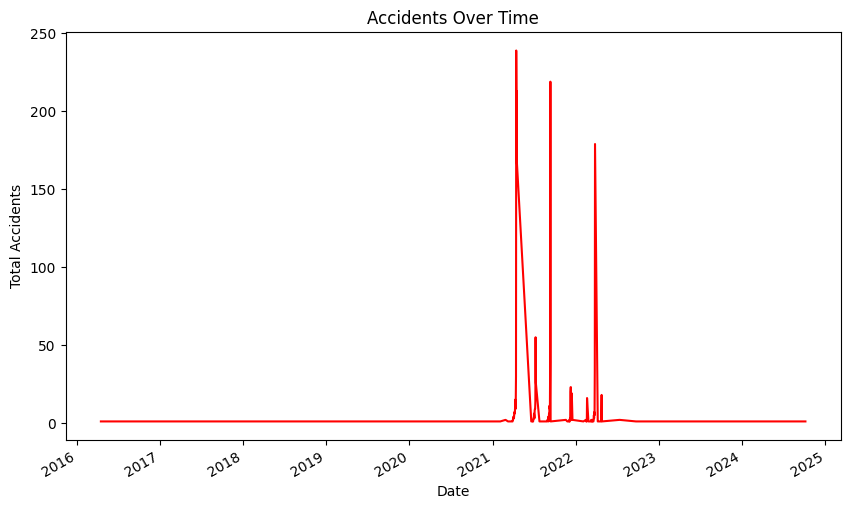

In [8]:
#1.daily_accident_summary
query = "SELECT * FROM daily_accident_summary"
df_daily = pd.read_sql(query, engine)

# Convert accident_date to datetime
df_daily['accident_date'] = pd.to_datetime(df_daily['accident_date'])
df_daily['day_of_week'] = df_daily['accident_date'].dt.day_name()

# Plot the total number of accidents by date
plt.figure(figsize=(10, 6))
df_daily.groupby('accident_date')['total_accidents'].sum().plot(kind='line', color='red')
plt.title('Accidents Over Time')
plt.xlabel('Date')
plt.ylabel('Total Accidents')
plt.show()

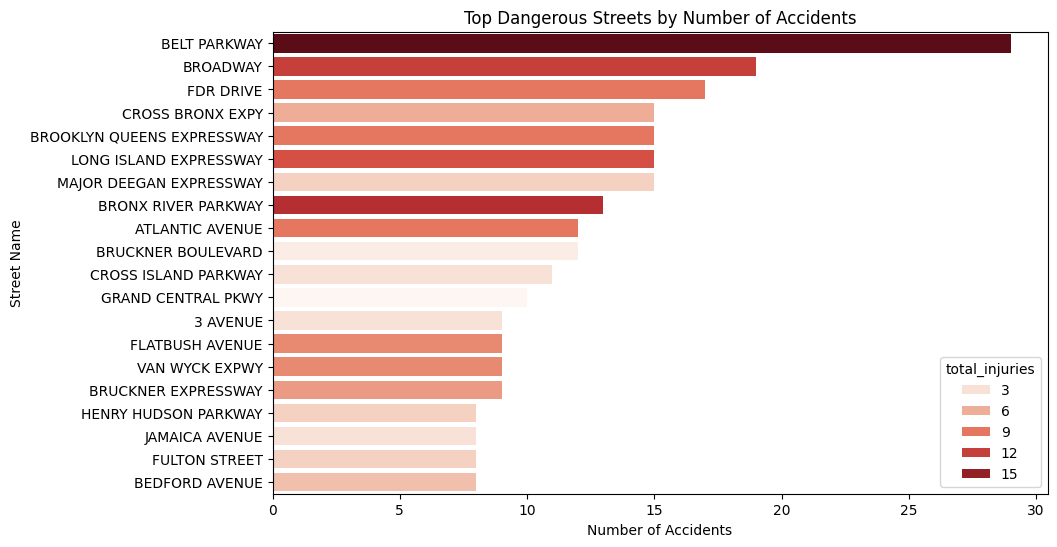

In [9]:
#2.top_dangerous_streets
query = "SELECT * FROM top_dangerous_streets"
df_streets = pd.read_sql(query, engine)

# Plot the most dangerous streets
plt.figure(figsize=(10, 6))
sns.barplot(x='accident_count', y='on_street_name', data=df_streets, palette='Reds',hue='total_injuries')
plt.title('Top Dangerous Streets by Number of Accidents')
plt.xlabel('Number of Accidents')
plt.ylabel('Street Name')
plt.show()

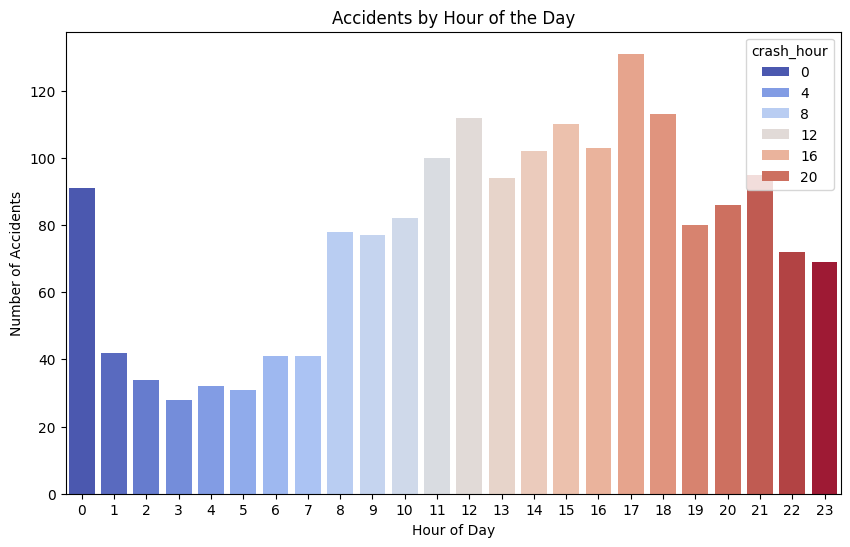

In [10]:
#3. Hourly accident distribution
query = "SELECT * FROM hourly_accident_distribution"
df_hourly = pd.read_sql(query, engine)

# Plot accidents by hour
plt.figure(figsize=(10, 6))
sns.barplot(x='crash_hour', y='accident_count', data=df_hourly, hue='crash_hour', palette='coolwarm')
plt.title('Accidents by Hour of the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Accidents')
plt.show()

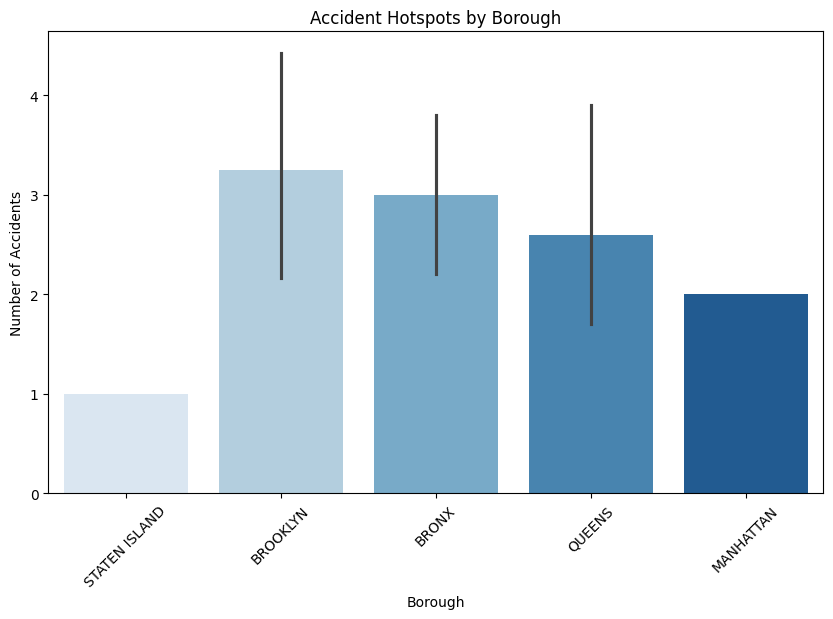

In [11]:
#4.borough_street_hotspots
query = "SELECT * FROM borough_street_hotspots"
df_borough_hotspots = pd.read_sql(query, engine)

# Plot borough accident hotspots
plt.figure(figsize=(10, 6))
sns.barplot(x='borough', y='total_accidents', data=df_borough_hotspots, hue='borough',palette='Blues')
plt.title('Accident Hotspots by Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45)
plt.show()

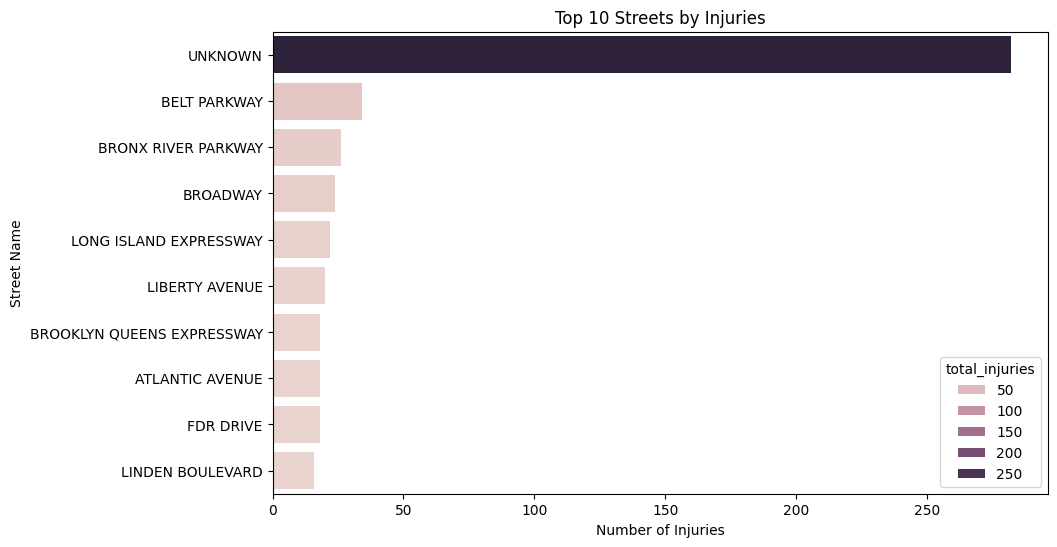

In [12]:
#5.Top10_streets_by_injuries
query = "SELECT * FROM vw_top_10_streets_by_injuries"
df_top_streets = pd.read_sql(query, engine)

# Plot the top 10 streets by injuries
plt.figure(figsize=(10, 6))
sns.barplot(x='total_injuries', y='on_street_name', data=df_top_streets, hue='total_injuries')
plt.title('Top 10 Streets by Injuries')
plt.xlabel('Number of Injuries')
plt.ylabel('Street Name')
plt.show()

Forecasting

In [16]:
df_transformed.columns

Index(['crash_date', 'crash_time', 'on_street_name', 'off_street_name',
       'number_of_persons_injured', 'number_of_persons_killed',
       'number_of_pedestrians_injured', 'number_of_pedestrians_killed',
       'number_of_cyclist_injured', 'number_of_cyclist_killed',
       'number_of_motorist_injured', 'number_of_motorist_killed',
       'contributing_factor_vehicle_1', 'contributing_factor_vehicle_2',
       'collision_id', 'vehicle_type_code1', 'vehicle_type_code2', 'borough',
       'zip_code', 'latitude', 'longitude', 'location',
       'contributing_factor_vehicle_3', 'vehicle_type_code_3',
       'cross_street_name', 'contributing_factor_vehicle_4',
       'vehicle_type_code_4', 'contributing_factor_vehicle_5',
       'vehicle_type_code_5'],
      dtype='object')

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

In [29]:
#1.Predict the Borough Where the Accident is Likely to Occur
#Extract the hour and day of week
df_transformed['crash_date'] = pd.to_datetime(df_transformed['crash_date'])
df_transformed['crash_hour'] = pd.to_datetime(df_transformed['crash_time'], format='%H:%M', errors='coerce').dt.hour
df_transformed['day_of_week'] = df_transformed['crash_date'].dt.day_name()

In [ ]:
# Define your target variable (borough)
target = 'borough'

# Select features (excluding 'borough' from the features list)
features = ['crash_hour', 'day_of_week', 'number_of_persons_injured', 'number_of_persons_killed', 
            'number_of_pedestrians_injured', 'number_of_cyclist_injured', 'number_of_motorist_injured']

# Drop rows with missing target values
df_transformed = df_transformed.dropna(subset=[target])

# Select the features and target from the dataframe
X = df_transformed[features]
y = df_transformed[target]

# Convert categorical columns to numerical (e.g., borough)
X = pd.get_dummies(X, columns=['day_of_week'], drop_first=True)

# Split data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Classifier model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

In [34]:
from sklearn.metrics import classification_report, confusion_matrix

# Classification report with zero_division set to 1
print(classification_report(y_test, y_pred, zero_division=1))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

               precision    recall  f1-score   support

        BRONX       0.25      0.09      0.14        43
     BROOKLYN       0.28      0.27      0.27       101
    MANHATTAN       0.12      0.12      0.12        32
       QUEENS       0.20      0.24      0.22        66
STATEN ISLAND       1.00      0.00      0.00        11
      UNKNOWN       0.32      0.40      0.36       116

     accuracy                           0.26       369
    macro avg       0.36      0.19      0.18       369
 weighted avg       0.28      0.26      0.25       369

Confusion Matrix:
[[ 4 12  2  8  0 17]
 [ 4 27 10 24  0 36]
 [ 1  6  4  8  0 13]
 [ 1 20  4 16  0 25]
 [ 0  3  2  1  0  5]
 [ 6 30 10 24  0 46]]


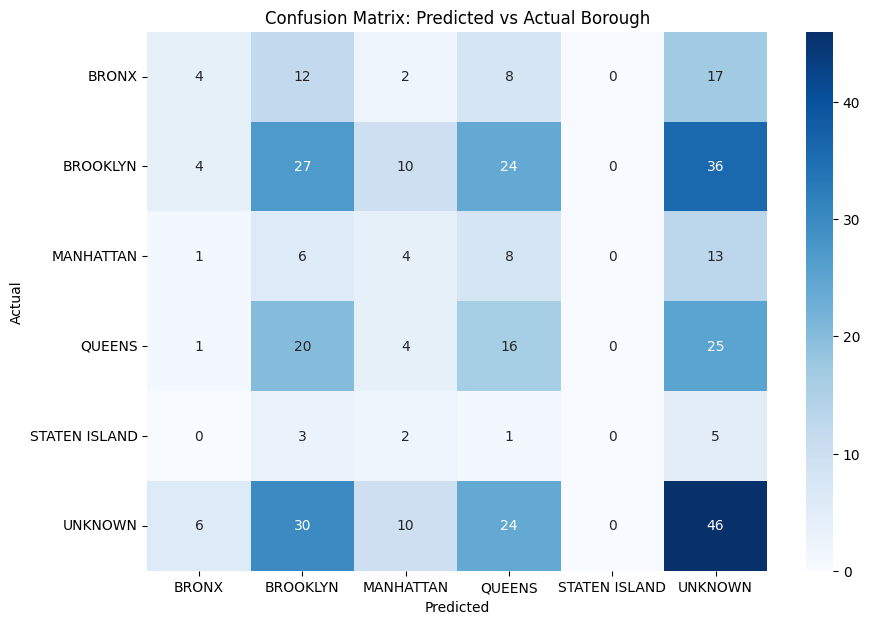

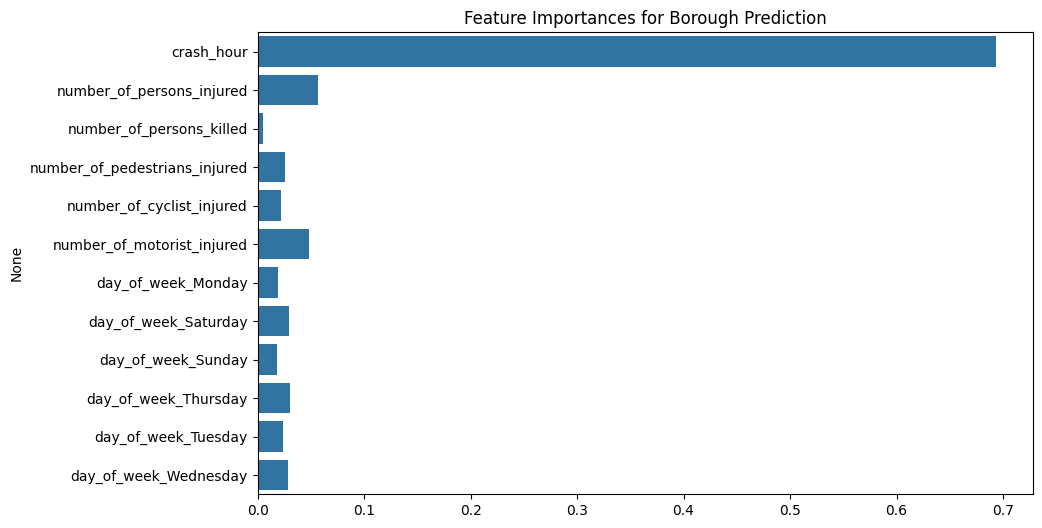

In [35]:
# Visualize the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix: Predicted vs Actual Borough')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature importance visualization
feature_importances = model.feature_importances_
features = X.columns
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=features)
plt.title('Feature Importances for Borough Prediction')
plt.show()

In [38]:
#2.Time series analysis
df_transformed.set_index('crash_date', inplace=True)
daily_accidents = df_transformed.resample('D').size()  # Daily accident counts

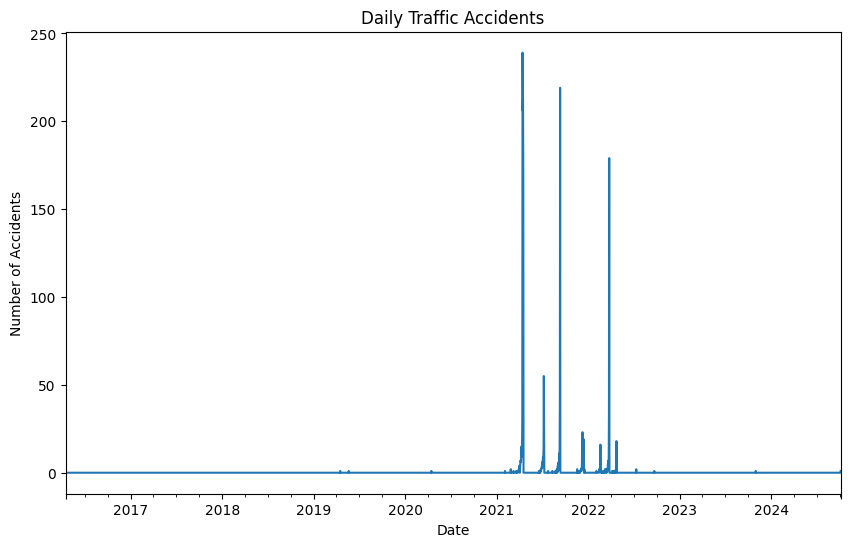

In [39]:
daily_accidents.plot(figsize=(10, 6))
plt.title('Daily Traffic Accidents')
plt.xlabel('Date')
plt.ylabel('Number of Accidents')
plt.show()

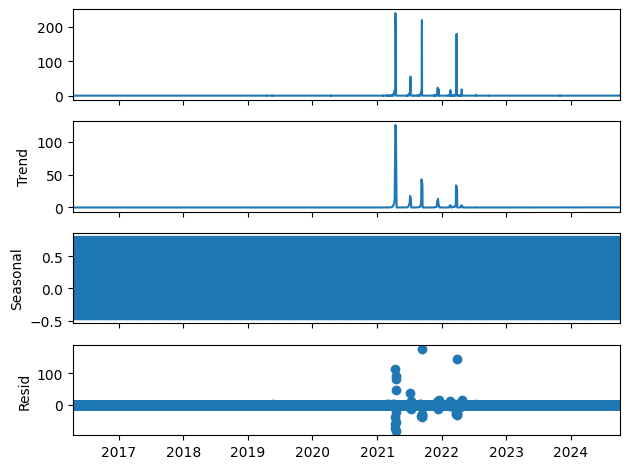

In [41]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(daily_accidents, model='additive')
decomposition.plot()
plt.show()

In [42]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(daily_accidents)
print(f'p-value: {result[1]}')  # If p-value < 0.05, the series is stationary.

p-value: 2.3141394189567843e-30


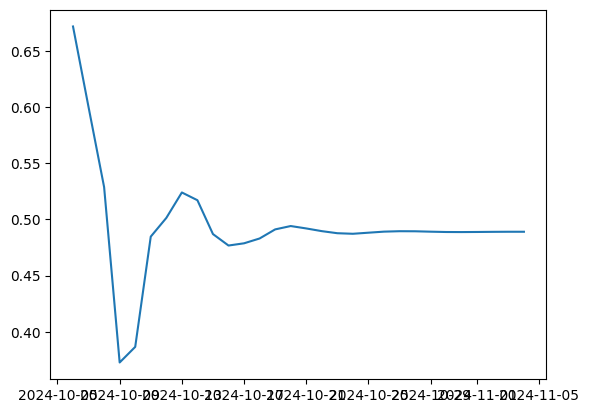

In [43]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(daily_accidents, order=(5, 1, 0))  # Example parameters
model_fit = model.fit()
forecast = model_fit.forecast(steps=30)  # Forecast next 30 days
plt.plot(forecast)
plt.show()